# BOFire Reaction Optimisation Tutorial

> **Adapted from** the official [BOFire reaction optimisation tutorial](https://github.com/experimental-design/bofire/blob/main/tutorials/basic_examples/Reaction_Optimization_Example.ipynb).

<p align="left">
<a href="https://colab.research.google.com/github/austin-mroz/4-BO-for-chemistry/blob/main/main/tutorial-notebooks/AIMS_BOFire.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Google Colab">
</a>
</p>


## 🎯 Learning Objectives

This notebook teaches Bayesian Optimisation (BO) for chemical reaction optimisation using the `bofire` library.  
By the end you should be able to:

| Bloom's Level | What you will do |
|---|---|
| **Remember** | Recall what a `Domain`, `Input`, `Output`, and `Objective` are in BOFire |
| **Understand** | Explain the BO loop: *ask → evaluate → tell* |
| **Apply** | Run a single-objective BO loop to maximise reaction yield |
| **Analyse** | Inspect the optimisation history and identify trends |
| **Evaluate** | Assess when BO has converged and what the best conditions are |
| **Create** | Extend the setup to a **multi-objective** BO problem (yield vs. TON) |

---

### Background: What is Bayesian Optimisation?

Bayesian Optimisation is a sequential, model-based strategy for optimising **expensive black-box functions** — functions where each evaluation is costly (time, reagents, money).  
It works by:

1. **Fitting a surrogate model** (typically a Gaussian Process) to data collected so far.
2. **Maximising an acquisition function** derived from the surrogate to decide the *most promising* next experiment.
3. **Evaluating** the experiment and updating the model.
4. Repeating until budget is exhausted or a satisfactory result is found.

In chemistry, the "function" is the reaction: inputs are conditions (temperature, catalyst, etc.), output is the yield.  
BO lets us find good conditions in far fewer experiments than random or grid search.

---

### The Chemistry: Suzuki–Miyaura Cross-Coupling

We optimise a **Suzuki–Miyaura** palladium-catalysed cross-coupling reaction.  
The emulator is the pre-trained **Reizman–Suzuki** neural network from the `summit` package, trained on real experimental data.

**Variables we control:**
- Temperature (°C)
- Catalyst loading (%)
- Residence time (seconds)
- Catalyst identity (8 palladium catalyst/ligand combinations)

**What we measure:** Yield (%), and Turnover Number (TON) — a measure of catalyst efficiency.


In [35]:
# ─── Installation ────────────────────────────────────────────────────────
# Run this cell once to install all required packages.
# bofire[optimization,cheminfo] pulls in BoTorch, GPyTorch, and RDKit support.
# summit provides the pre-trained Suzuki–Miyaura reaction emulator.
!pip install requests gauche 'bofire[optimization,cheminfo]' matplotlib rdkit

In [36]:
# ─── Core imports ────────────────────────────────────────────────────────
# pandas  : tabular data manipulation (DataFrames for experiments)
# numpy   : numerical arrays (used by surrogate model internals)
# matplotlib: plotting the optimisation history
# time    : benchmarking how long each BO step takes
from pprint import pprint as pp
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import os

---

## Part 1 — Defining the Optimisation Problem as a BOFire `Domain`

### 🧠 Concept: The Domain

Before BO can run, we must formally describe **what we are optimising**.  
In BOFire this description is called a **`Domain`** object.  A Domain bundles together:

| Component | BOFire class | Purpose |
|---|---|---|
| **Inputs** | `ContinuousInput`, `CategoricalInput` | The reaction knobs we can turn |
| **Outputs** | `ContinuousOutput` | The response(s) we measure |
| **Objectives** | `MaximizeObjective`, `MinimizeObjective` | How to judge "good" |

Think of the Domain as the equivalent of writing a **design of experiments (DoE) protocol**: you declare what variables exist and what their ranges are, before you run a single experiment.

### Our reaction variables

| Feature | Type | Bounds / Options | Chemistry rationale |
|---|---|---|---|
| Temperature | `ContinuousInput` | 30–110 °C | Typical range for Pd-catalysis; higher T can improve kinetics but degrade selectivity |
| Catalyst Loading | `ContinuousInput` | 0.5–2 mol% | Low loading = efficient; high = faster but wasteful |
| Residence Time | `ContinuousInput` | 1–10 min | Flow chemistry timescale; longer = more conversion |
| Catalyst | `CategoricalInput` | 8 Pd catalyst/ligand combos | Ligand identity is the dominant discrete choice in Suzuki reactions |
| **Yield** | `ContinuousOutput` | 0-100% | Target response |

> **Note:** The `key` argument is the column name that will appear in all DataFrames — keep it consistent throughout the notebook.


In [37]:
# Import the core BOFire classes we need to describe the problem.
# Domain         : container for the whole problem definition
# Inputs/Outputs  : typed collections of input/output features
# ContinuousInput : a real-valued variable with lower and upper bounds
# ContinuousOutput: a real-valued response variable
# CategoricalInput: a variable that takes one of a fixed set of string labels
from bofire.data_models.domain.api import Domain
from bofire.data_models.domain.api import Inputs, Outputs
from bofire.data_models.features.api import (
    ContinuousInput,
    ContinuousOutput,
    CategoricalInput,
    CategoricalDescriptorInput,
)  # We won't need CategoricalDescriptorInput in Part 1, but it's imported for Part 2.

In [38]:
# ── Continuous input features ────────────────────────────────────────────
# Each ContinuousInput requires:
#   key    : unique string identifier (matches DataFrame column name later)
#   bounds : [lower, upper] — the feasible range
#   unit   : metadata only (BOFire does not rescale automatically)

# Temperature: 30–110 °C, a standard range for Pd-catalysed reactions in flow.
temperature_feature = ContinuousInput(
    key="Temperature", bounds=[30.0, 110.0], unit="°C"
)

# Catalyst loading in mol %.
# 0.5 % is already quite low; above 2 % gives diminishing returns in most protocols.
catalyst_loading_feature = ContinuousInput(
    key="Catalyst Loading", bounds=[0.5, 2], unit="%"
)

# Residence time in seconds (1 min = 60 s, 10 min = 600 s).
# Note: bounds are passed as numbers, so we compute them inline.
residence_time_feature = ContinuousInput(
    key="Residence Time", bounds=[1 * 60, 10 * 60], unit="minutes"
)

# ── Categorical input feature ─────────────────────────────────────────────
# Each element of 'categories' is one allowed string value.
# The naming convention 'P{precatalyst}-L{ligand}' is inherited from the summit dataset.
catalyst_feature = CategoricalInput(
    key="Catalyst",
    categories=[
        "P1-L1",  # Pd(OAc)₂ / SPhos family
        "P2-L1",
        "P1-L2",
        "P1-L3",
        "P1-L4",
        "P1-L5",
        "P1-L6",
        "P1-L7",
    ],
)

# ── Collect all inputs into an Inputs container ───────────────────────────
# Order matters for readability; BOFire does not enforce any particular order.
input_features = Inputs(
    features=[
        temperature_feature,
        catalyst_loading_feature,
        residence_time_feature,
        catalyst_feature,
    ]
)

In [39]:
# ── Output feature and objective ─────────────────────────────────────────
# MaximizeObjective tells BO to seek HIGHER values of this output.
#   w=1.0 : the weight (useful in multi-objective settings; 1.0 = treat equally)
# The bounds of the objective (0, 1) specify the normalisation range BOFire uses
# internally when converting raw outputs to 'desirability' scores.
from bofire.data_models.objectives.api import MaximizeObjective

objective = MaximizeObjective(
    w=1.0,  # Weight; relevant when combining multiple objectives
)

# Wrap the objective in a ContinuousOutput feature.
# 'Yield' is the key that must match the column returned by the emulator.
yield_feature = ContinuousOutput(key="Yield", objective=objective)

# Collect into an Outputs container.
output_features = Outputs(features=[yield_feature])

In [40]:
# Inspect the objective object to verify it was created correctly.
# You should see: MaximizeObjective(type='MaximizeObjective', w=1.0, bounds=(0, 1))
objective

MaximizeObjective(type='MaximizeObjective', w=1.0, bounds=[0, 1])

In [41]:
# Quick sanity-check: print a human-readable summary of our features.
# ✅ Check that bounds, units, and category lists look correct before proceeding.
print("input_features: ", input_features)
print("output_features:", output_features)

input_features:  type='Inputs' features=[ContinuousInput(type='ContinuousInput', key='Temperature', unit='°C', bounds=[30.0, 110.0], local_relative_bounds=None, stepsize=None, allow_zero=False), ContinuousInput(type='ContinuousInput', key='Catalyst Loading', unit='%', bounds=[0.5, 2.0], local_relative_bounds=None, stepsize=None, allow_zero=False), ContinuousInput(type='ContinuousInput', key='Residence Time', unit='minutes', bounds=[60.0, 600.0], local_relative_bounds=None, stepsize=None, allow_zero=False), CategoricalInput(type='CategoricalInput', key='Catalyst', categories=['P1-L1', 'P2-L1', 'P1-L2', 'P1-L3', 'P1-L4', 'P1-L5', 'P1-L6', 'P1-L7'], allowed=[True, True, True, True, True, True, True, True])]
output_features: type='Outputs' features=[ContinuousOutput(type='ContinuousOutput', key='Yield', unit=None, objective=MaximizeObjective(type='MaximizeObjective', w=1.0, bounds=[0, 1]))]


In [42]:
# ── Assemble the Domain ──────────────────────────────────────────────────
# The Domain bundles inputs + outputs into a single object.
# Every BOFire strategy and sampler requires a Domain at construction time.
# No experiments have been run yet — we are just declaring the search space.
domain = Domain(
    inputs=input_features,
    outputs=output_features,
)

### ✅ Domain Summary

The table rendered by the next cell summarises the domain we just defined.
Use it as a **sanity check** before running any experiments:

- Continuous inputs show their `[lower, upper]` bounds.
- The categorical catalyst shows how many options are allowed.
- `ContinuousOutputFeature` for Yield confirms that it is a real-valued response.

> 💡 **Question to consider:** Do these bounds make chemical sense?  
> Would you expect a Pd-catalysed coupling to work at 30 °C with a 1-minute residence time?


In [43]:
# Pretty-print the domain as a pandas DataFrame.
# 'get_reps_df()' concatenates inputs and outputs and renders their types and bounds.
(domain.inputs + domain.outputs).get_reps_df()

,Type,Description
Catalyst Loading,ContinuousInput,"[0.5,2.0]"
Residence Time,ContinuousInput,"[60.0,600.0]"
Temperature,ContinuousInput,"[30.0,110.0]"
Catalyst,CategoricalInput,8 categories
Yield,ContinuousOutput,ContinuousOutputFeature


In [44]:
# You can also iterate over the features programmatically.
# 'get_keys()' returns a list of feature names (the 'key' strings we defined).
# 'get_by_key(key)' retrieves the full feature object for inspection or modification.
for feature_key in domain.inputs.get_keys():
    input_feature = domain.inputs.get_by_key(feature_key)
    print(feature_key, "|", input_feature)

Catalyst Loading | [0.5,2.0]
Residence Time | [60.0,600.0]
Temperature | [30.0,110.0]
Catalyst | 8 categories


In [45]:
# Same pattern for output features.
# Here we use __repr__() to see the full objective specification.
for feature_key in domain.outputs.get_keys():
    output_feature = domain.outputs.get_by_key(feature_key)
    print(feature_key, " | ", output_feature.__repr__())

Yield  |  ContinuousOutput(type='ContinuousOutput', key='Yield', unit=None, objective=MaximizeObjective(type='MaximizeObjective', w=1.0, bounds=[0, 1]))


In [46]:
# Re-confirm the domain looks correct after all cells have run in sequence.
(domain.inputs + domain.outputs).get_reps_df()

,Type,Description
Catalyst Loading,ContinuousInput,"[0.5,2.0]"
Residence Time,ContinuousInput,"[60.0,600.0]"
Temperature,ContinuousInput,"[30.0,110.0]"
Catalyst,CategoricalInput,8 categories
Yield,ContinuousOutput,ContinuousOutputFeature


---

## Part 2 — The Virtual Lab: A Pre-trained Reaction Emulator

### 🧠 Concept: Why an emulator?

In a real lab, each experiment takes time and costs reagents.  
For learning purposes we replace the wet-lab with a **pre-trained neural network emulator** from the `summit` package.  
The emulator was fitted to the Reizman Suzuki dataset and predicts yield and TON for any set of conditions within our domain.

We will define a function `perform_experiment` below. This is equivalent to running the reaction in the lab and measuring the outcome.

### Name mapping between BOFire and summit

BOFire and summit use different column name conventions.  
The `name_map` dictionary below translates our BOFire keys into the names the emulator expects:

| BOFire key | Summit key |
|---|---|
| `Catalyst Loading` | `catalyst_loading` |
| `Residence Time` | `t_res` |
| `Temperature` | `temperature` |
| `Catalyst` | `catalyst` |
| `Yield` | `yld` |

### The `valid_*` flag

BOFire expects every output column to have a matching `valid_<key>` column (e.g. `valid_Yield`).  
A value of `1` means the measurement is valid and should be used in model fitting.  
A value of `0` means the measurement should be ignored (e.g. it failed, or was an outlier).


In [47]:
import numpy as np
import requests

# ── Name translation map ──────────────────────────────────────────────────
# Maps BOFire column names → summit emulator column names.
name_map = {
    "Catalyst Loading": "catalyst_loading",
    "Residence Time": "t_res",
    "Temperature": "temperature",
    "Catalyst": "catalyst",
    "Yield": "yield",
    "TON": "ton",
}

# ── Build a single test candidate DataFrame ───────────────────────────────
# This is one set of conditions we want to evaluate — a "test run" to check
# that our domain definition and the emulator are compatible.
candidates = {
        "Catalyst Loading": [0.498],   # mol%
        "Residence Time": [600],       # seconds (= 10 min)
        "Temperature": [30],           # °C (lower bound of our domain)
        "Catalyst": ["P1-L3"],
    }
renamed_candidates = [
    {name_map.get(k, k): v[0] for k, v in candidates.items()}
]
print(renamed_candidates)

def perform_experiment(candidates):
    url = "https://suprashare.rcs.ic.ac.uk/web-bo/perform-experiment"

    with requests.Session() as session:
        result = session.post(url, json=candidates)

    return result.json()

# run_experiments returns predicted Yield (and TON) for our test candidate.
# We immediately rename the columns back to BOFire conventions.
results = perform_experiment(renamed_candidates)[0]
print(results)

# ── Format as a BOFire experiments DataFrame ─────────────────────────────
# BOFire expects: all input columns + all output columns + valid_<output> flags.
# valid_Yield = 1 means "this measurement is trustworthy; use it for model fitting".
experiments = {
        "Catalyst Loading": results["catalyst_loading"],
        "Residence Time": results["t_res"],
        "Temperature": results["temperature"],
        "Catalyst": results["catalyst"],
        "Yield": results["yield"],
        "valid_Yield": 1,  # Mark as valid for the surrogate model
    }

[{'catalyst_loading': 0.498, 't_res': 600, 'temperature': 30, 'catalyst': 'P1-L3'}]
{'catalyst': 'P1-L3', 'catalyst_loading': 0.498, 'iteration': 0, 't_res': 600, 'temperature': 30, 'ton': 0.0, 'yield': 0.1693080366}


In [48]:
# Inspect the emulator output.
# You should see Yield ≈ 0.17 for this low-temperature, long-residence-time test point.
# Note that Yield here is a raw emulator value — the actual % yield is Yield × 100.
experiments

{'Catalyst Loading': 0.498,
 'Residence Time': 600,
 'Temperature': 30,
 'Catalyst': 'P1-L3',
 'Yield': 0.1693080366,
 'valid_Yield': 1}

---

## Part 3 — Setting Up the Bayesian Optimisation Strategy

### 🧠 Concept: The BO Loop

Every Bayesian Optimisation algorithm revolves around two operations:

```
┌─────────────┐    ask()     ┌──────────────────────┐
│  BO Strategy│ ──────────▶ │ New candidate         │
│  (surrogate │             │ conditions to test    │
│   + acqf)   │ ◀────────── │                      │
└─────────────┘    tell()   └──────────────────────┘
                              ▼
                        Run experiment
                        (emulator here)
```

| Method | What it does |
|---|---|
| `strategy.ask(n)` | Returns `n` candidate experiments, chosen by the acquisition function |
| `strategy.tell(experiments)` | Adds new observations and **refits the surrogate model** |

### 🧠 Concept: Single-Objective BO (`SoboStrategy`)

`SoboStrategy` optimises **one output** at a time — here, just `Yield`.  
Internally it fits a **Gaussian Process (GP)** surrogate and uses the `qEI` (batched Expected Improvement) acquisition function to propose the next experiment.

**Expected Improvement (EI)** balances:
- **Exploitation**: sampling where the GP predicts high yield.
- **Exploration**: sampling where the GP is uncertain (high variance), because there might be undiscovered good regions.

The `q` in `qEI` stands for *quasi-Monte Carlo*, allowing us to propose batches of `q > 1` experiments simultaneously — useful when experiments can be parallelised.


In [49]:
# SoboStrategy : Single-OBjective BOFire strategy
# qEI          : quasi-Monte Carlo Expected Improvement acquisition function
# strategies   : the 'map' function turns a data-model into a runnable strategy
from bofire.data_models.strategies.api import SoboStrategy
from bofire.data_models.acquisition_functions.api import qEI

import bofire.strategies.api as strategies

In [50]:
# ── Configure the acquisition function ───────────────────────────────────
# qEI() uses default settings (MC samples, batch size controlled by ask()).
qExpectedImprovement = qEI()

# ── Build the SOBO data model ─────────────────────────────────────────────
# BOFire separates 'data models' (configuration objects) from
# 'strategies' (objects with .ask()/.tell() functionality).
# Step 1: create the data model with domain + acquisition function.
sobo_strategy_data_model = SoboStrategy(
    domain=domain,
    acquisition_function=qExpectedImprovement,
)

# Step 2: call strategies.map() to convert to a runnable strategy object.
# This is analogous to sklearn's .fit() — it initialises the internal state.
sobo_strategy = strategies.map(sobo_strategy_data_model)

In [51]:
# Feed the single test experiment we ran earlier to the strategy.
# With only 1 data point the GP cannot be meaningfully fitted yet,
# but this initialises the strategy's internal 'experiments' store.
# We will replace this with 5 random experiments in the next section.
sobo_strategy.tell(pd.DataFrame([experiments]))

---

## Part 4 — Initialisation with Random Experiments

### 🧠 Why do we need initial data?

A GP surrogate needs **at least a few data points** to build a meaningful model.  
With zero data, every point in the space looks equally promising and EI cannot discriminate.

A standard approach is **Latin Hypercube Sampling (LHS)** or simple **random sampling** to spread the initial points across the space.  
Here we use `RandomStrategy` which samples uniformly at random within the domain bounds.

**Rule of thumb:** Use at least `5 × number_of_inputs` random initial experiments before switching to BO.  
With 4 inputs we use 5 random points — the absolute minimum.

> 💡 **Try this:** Change `ask(5)` to `ask(20)` and re-run the BO loop below.  
> Does more initial data help BO converge faster?


In [52]:
# ── Build a RandomStrategy ───────────────────────────────────────────────
# RandomStrategy ignores any prior data and simply samples uniformly at random
# within the domain bounds, respecting categorical constraints.
from bofire.data_models.strategies.api import (
    RandomStrategy as RandomStrategyModel,
)

random_strategy_model = RandomStrategyModel(domain=domain)
# As with SoboStrategy, we need strategies.map() to get a runnable object.
random_strategy = strategies.map(random_strategy_model)

In [53]:
# Quick check: the domain is stored inside the strategy.
# Confirm it still matches our original definition.
domain

Domain(type='Domain', inputs=Inputs(type='Inputs', features=[ContinuousInput(type='ContinuousInput', key='Temperature', unit='°C', bounds=[30.0, 110.0], local_relative_bounds=None, stepsize=None, allow_zero=False), ContinuousInput(type='ContinuousInput', key='Catalyst Loading', unit='%', bounds=[0.5, 2.0], local_relative_bounds=None, stepsize=None, allow_zero=False), ContinuousInput(type='ContinuousInput', key='Residence Time', unit='minutes', bounds=[60.0, 600.0], local_relative_bounds=None, stepsize=None, allow_zero=False), CategoricalInput(type='CategoricalInput', key='Catalyst', categories=['P1-L1', 'P2-L1', 'P1-L2', 'P1-L3', 'P1-L4', 'P1-L5', 'P1-L6', 'P1-L7'], allowed=[True, True, True, True, True, True, True, True])]), outputs=Outputs(type='Outputs', features=[ContinuousOutput(type='ContinuousOutput', key='Yield', unit=None, objective=MaximizeObjective(type='MaximizeObjective', w=1.0, bounds=[0, 1]))]), constraints=Constraints(type='Constraints', constraints=[]))

In [54]:
# Ask the random strategy for 5 candidate experiments.
# Each call to ask() returns a fresh DataFrame of proposed conditions.
# Note: because this is random, your results will differ each run.
# Set numpy/torch seeds if you need reproducibility.
candidates = random_strategy.ask(5)

In [55]:
# Inspect the 5 random candidates.
# ✅ Check: all Temperature values should be in [30, 110],
#           Residence Time in [60, 600], Catalyst Loading in [0.5, 2],
#           and Catalyst should be one of the 8 allowed strings.
candidates

,Catalyst Loading,Residence Time,Temperature,Catalyst
0,1.206080,547.035585,37.488820,P1-L3
1,1.746976,74.989406,47.673239,P1-L4
2,1.281207,181.548854,50.923610,P1-L6
3,1.966485,143.656247,108.770641,P1-L2
4,1.101890,321.811991,44.389048,P1-L1


### Reflection on the random candidates

Notice that the 5 candidates above cover the space **broadly but unevenly** — that is the nature of random sampling.  
You might have two points at similar temperatures but very different residence times.  
This is acceptable for initialisation; BO will fill in the gaps intelligently in later iterations.

> 💡 **Chemistry question:** Before running the emulator, which of these 5 conditions do you predict will give the highest yield? Why?


### Evaluating the random candidates

We now pass the 5 candidate conditions to `perform_experiment`, which:
1. Renames columns to match the summit convention.
2. Calls the pre-trained emulator.
3. Returns a DataFrame with `Yield`, `TON`, `valid_Yield`, and `valid_TON`.

This DataFrame is our **initial experimental dataset** that BO will learn from.


In [ ]:
# Evaluate all 5 candidates at once.
# In a real lab you would run these experiments in parallel or sequentially
# and record the yield measurements manually.
renamed_candidates = candidates.rename(columns=name_map)
renamed_candidates = renamed_candidates.to_dict(orient="records")

experiments = []
for candidate in renamed_candidates:
  experimental_result = perform_experiment([candidate])
  print(experimental_result)
  experiments.append(experimental_result)
  print('-------')

[{'catalyst_loading': 1.2060800582829747, 't_res': 547.035585419409, 'temperature': 37.488819627226235, 'catalyst': 'P1-L3'}, {'catalyst_loading': 1.7469758713936312, 't_res': 74.98940584314653, 'temperature': 47.67323921441644, 'catalyst': 'P1-L4'}, {'catalyst_loading': 1.281207143039848, 't_res': 181.5488540630676, 'temperature': 50.923609506475664, 'catalyst': 'P1-L6'}, {'catalyst_loading': 1.966485009580507, 't_res': 143.65624650034536, 'temperature': 108.77064088787043, 'catalyst': 'P1-L2'}, {'catalyst_loading': 1.1018904602307324, 't_res': 321.81199104503094, 'temperature': 44.38904758030318, 'catalyst': 'P1-L1'}]
{'catalyst_loading': 1.2060800582829747, 't_res': 547.035585419409, 'temperature': 37.488819627226235, 'catalyst': 'P1-L3'}
[{'catalyst': 'P1-L3', 'catalyst_loading': 1.2060800583, 'iteration': 0, 't_res': 547.0355854194, 'temperature': 37.4888196272, 'ton': 0.0, 'yield': 3.9907886982}]
-------
{'catalyst_loading': 1.7469758713936312, 't_res': 74.98940584314653, 'temper

In [57]:
# Inspect the evaluated experiments.
# Each row is one reaction run. Key columns:
#   Yield      : predicted yield from the emulator (raw, multiply by 100 for %)
#   TON        : turnover number — a measure of catalyst efficiency
#   valid_Yield: 1 = this point should be included in model training
#   valid_TON  : same validity flag for TON
experiments

[[{'catalyst': 'P1-L3',
   'catalyst_loading': 1.2060800583,
   'iteration': 0,
   't_res': 547.0355854194,
   'temperature': 37.4888196272,
   'ton': 0.0,
   'yield': 3.9907886982}],
 [{'catalyst': 'P1-L4',
   'catalyst_loading': 1.7469758714,
   'iteration': 0,
   't_res': 74.9894058431,
   'temperature': 47.6732392144,
   'ton': 0.0,
   'yield': 9.1938076019}],
 [{'catalyst': 'P1-L6',
   'catalyst_loading': 1.281207143,
   'iteration': 0,
   't_res': 181.5488540631,
   'temperature': 50.9236095065,
   'ton': 0.0,
   'yield': 0.0}],
 [{'catalyst': 'P1-L2',
   'catalyst_loading': 1.9664850096,
   'iteration': 0,
   't_res': 143.6562465003,
   'temperature': 108.7706408879,
   'ton': 0.0,
   'yield': 41.4466705322}],
 [{'catalyst': 'P1-L1',
   'catalyst_loading': 1.1018904602,
   'iteration': 0,
   't_res': 321.811991045,
   'temperature': 44.3890475803,
   'ton': 0.0,
   'yield': 12.5757980347}]]

### Updating the BO strategy with initial data

We now pass these 5 experiments to the SOBO strategy via `tell()`.  
- `replace=True` discards the single test point from earlier and replaces it with our 5-point dataset.  
- `retrain=True` immediately fits the GP surrogate on the new data.

After this call, the GP has a rough model of the yield landscape.  
The next `ask()` call will use this model to suggest a smarter experiment than random sampling.


In [ ]:
import time

t1 = time.time()

# replace=True : overwrite the earlier single-point dataset
# retrain=True  : fit the GP surrogate immediately (otherwise it fits lazily at ask() time)

# we first need to flatten the list of experiment dicts into a single DataFrame before passing to tell()
flattened = [item for sublist in experiments for item in sublist]
df = pd.DataFrame(flattened)
reverse_name_map = {v: k for k, v in name_map.items()}
experiment_result_df = df.rename(columns=reverse_name_map)

print(experiment_result_df)
sobo_strategy.tell(experiment_result_df, replace=True, retrain=True)

print(f"GP fitting took {(time.time()-t1):.2f} seconds")

[[{'catalyst': 'P1-L3', 'catalyst_loading': 1.2060800583, 'iteration': 0, 't_res': 547.0355854194, 'temperature': 37.4888196272, 'ton': 0.0, 'yield': 3.9907886982}], [{'catalyst': 'P1-L4', 'catalyst_loading': 1.7469758714, 'iteration': 0, 't_res': 74.9894058431, 'temperature': 47.6732392144, 'ton': 0.0, 'yield': 9.1938076019}], [{'catalyst': 'P1-L6', 'catalyst_loading': 1.281207143, 'iteration': 0, 't_res': 181.5488540631, 'temperature': 50.9236095065, 'ton': 0.0, 'yield': 0.0}], [{'catalyst': 'P1-L2', 'catalyst_loading': 1.9664850096, 'iteration': 0, 't_res': 143.6562465003, 'temperature': 108.7706408879, 'ton': 0.0, 'yield': 41.4466705322}], [{'catalyst': 'P1-L1', 'catalyst_loading': 1.1018904602, 'iteration': 0, 't_res': 321.811991045, 'temperature': 44.3890475803, 'ton': 0.0, 'yield': 12.5757980347}]]
  Catalyst  Catalyst Loading  iteration  Residence Time  Temperature  TON  \
0    P1-L3          1.206080          0      547.035585    37.488820  0.0   
1    P1-L4          1.746976 

---

## Part 5 — The First BO Proposal: `ask(1)`

We can now ask the strategy for **one new experiment**, guided by the GP and EI.

This step is **computationally more expensive** than random sampling because it requires:
1. Fitting a Gaussian Process (if not already fitted).
2. Optimising the acquisition function (EI) over the continuous + categorical space.

The returned DataFrame includes extra prediction columns:

| Column | Meaning |
|---|---|
| `Yield_pred` | GP mean prediction for yield at this point |
| `Yield_sd` | GP standard deviation (uncertainty) |
| `Yield_des` | Desirability score (what the acquisition function saw) |

> 💡 Look at `Yield_sd`: is the model confident or uncertain about its suggestion?  
> High uncertainty can mean BO is **exploring** a new region; low uncertainty means it is **exploiting** a known good region.


In [59]:
t1 = time.time()

# Ask for ONE new candidate.
# Internally this:
#  1. (Re)fits the GP on all data seen so far.
#  2. Maximises EI over the domain to find the most promising conditions.
#  3. Returns the argmax as a DataFrame.
new_candidate = sobo_strategy.ask(1)

print(f"BO proposal step took {(time.time()-t1):.2f} seconds")

/usr/local/lib/python3.12/dist-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


BO proposal step took 7.48 seconds


In [60]:
# Inspect the BO proposal.
# ✅ Compare Yield_pred with the best Yield in your random 'experiments' above.
# ✅ Notice which catalyst and temperature range BO is proposing — does it make chemical sense?
new_candidate

,Catalyst Loading,Residence Time,Temperature,Catalyst,Yield_pred,Yield_sd,Yield_des
0,2.0,600.0,110.0,P1-L1,38.846706,7.797887,38.846706


### What just happened?

The `ask()` step is the heart of Bayesian Optimisation.  
After only 5 random experiments the GP has learned enough to propose conditions that are  
**predicted to beat the current best** with high probability — that is what EI measures.

The longer compute time compared to random sampling reflects the cost of:
- GP optimisation (marginal likelihood maximisation).
- Multi-start acquisition function optimisation over a mixed (continuous + categorical) space.

---


## 🎯 Your Task: Implement the Full BO Loop

You now have all the building blocks.  
Your task is to write the **Bayesian optimisation loop** for this single-objective problem.

> What can you change from the `Domain` and `Strategy` that we have set up in order to improve the optimisation campaign?

**Budget:** 20 experiments (you can adjust this).

At each iteration you should:
1. Use `sobo_strategy.ask(1)` to propose **one new experiment**.
2. Evaluate it with `perform_experiment(new_candidate)`.
3. Update the strategy with `sobo_strategy.tell(new_experiment)`.
4. Repeat.

```python
# Pseudocode
experimental_budget = 20
i = 0

while i < experimental_budget:
    # 1. Ask BO for the next experiment
    new_candidate = sobo_strategy.ask(1)

    # 2. 'Run' the experiment (call the emulator)
    new_experiment = perform_experiment(new_candidate)

    # 3. Tell the strategy about the result (updates GP)
    sobo_strategy.tell(new_experiment)

    i += 1
```

> ⏱ **Timing note:** Each BO iteration can take 10–60 seconds because the GP is refitted from scratch at each step.  
> Start with a budget of 10 to check everything works, then increase.


### Solution

The loop below implements the BO cycle.  
Key implementation notes:

- `sobo_strategy.tell(new_experiment)` **without** `replace=True` **appends** the new point to the existing dataset and refits the GP.  This is the default incremental update mode.
- At the end, `sobo_strategy.experiments` contains the **complete history**: the 5 random initial points plus all BO-guided experiments.
- Each iteration prints wall-clock time so you can see how GP fitting cost changes as the dataset grows.


In [61]:
experimental_budget = 10  # ← Increase to 20-50 for a more thorough search
i = 0
done = False

while not done:
    i += 1
    t1 = time.time()

    # ── Step 1: Ask ────────────────────────────────────────────────────────
    # The strategy internally:
    #   a) refits the GP on all experiments seen so far
    #   b) maximises EI over the domain
    #   c) returns the argmax as a 1-row DataFrame
    new_candidate = sobo_strategy.ask(1)

    # ── Step 2: Evaluate ───────────────────────────────────────────────────
    # In a real lab this is where you run the reaction and measure yield.
    # Here we call the emulator instead.
    renamed_candidates = new_candidate.rename(columns=name_map)
    renamed_candidates = renamed_candidates.to_dict(orient="records")

    new_experiment = perform_experiment(renamed_candidates)

    df = pd.DataFrame(new_experiment)
    reverse_name_map = {v: k for k, v in name_map.items()}
    new_experiment_df = df.rename(columns=reverse_name_map)

    # ── Step 3: Tell ───────────────────────────────────────────────────────
    # Append the new observation to the strategy's internal dataset
    # and refit the GP (this happens automatically inside tell()).
    sobo_strategy.tell(new_experiment_df)

    print(f"Iteration {i:>3d} | Yield = {new_experiment_df['Yield'].values[0]:.3f} | "
          f"took {(time.time()-t1):.1f}s")

    if i >= experimental_budget:
        done = True

print("\nOptimisation complete!")
print(f"Best yield found: {sobo_strategy.experiments['Yield'].max():.3f}")

/usr/local/lib/python3.12/dist-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration   1 | Yield = 63.239 | took 10.8s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration   2 | Yield = 56.863 | took 10.8s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


...

Iteration   8 | Yield = 66.582 | took 8.1s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration   9 | Yield = 70.025 | took 9.3s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/monte_carlo.py:415: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration  10 | Yield = 67.477 | took 9.6s

Optimisation complete!
Best yield found: 70.030


---

## Part 6 — Investigating the Optimisation Results

### What to look for

Now that the BO loop has run, `sobo_strategy.experiments` holds the complete history.  
Work through the following analysis questions:

**Table analysis:**
- Which row has the highest `Yield`?
- Which catalyst appears most frequently in the high-yield experiments?
- Is there a clear temperature trend (do high-yield points cluster at high or low temperatures)?

**Plot analysis:**
- Does yield increase monotonically with iteration? (It should generally trend upward.)
- Are there any "dips" where BO tried a new region (exploration) before improving again?

> 💡 **Reflection:** The first 5 points (rows 0–4) are the random initialisation.  
> How quickly did BO surpass the best random point?


In [62]:
# Full experimental history: inputs + measured outputs for every run.
# Rows 0–4  : random initialisation experiments
# Rows 5+   : BO-guided experiments
sobo_strategy.experiments

,Catalyst,Catalyst Loading,iteration,Residence Time,Temperature,TON,Yield,valid_Yield,Yield_des,Yield_pred,Yield_sd
0,P1-L3,1.206080,0,547.035585,37.488820,0.0,3.990789,True,NaN,NaN,NaN
1,P1-L4,1.746976,0,74.989406,47.673239,0.0,9.193808,True,NaN,NaN,NaN
2,P1-L6,1.281207,0,181.548854,50.923610,0.0,0.000000,True,NaN,NaN,NaN
3,P1-L2,1.966485,0,143.656247,108.770641,0.0,41.446671,True,NaN,NaN,NaN
4,P1-L1,1.101890,0,321.811991,44.389048,0.0,12.575798,True,NaN,NaN,NaN
5,P1-L1,2.000000,0,600.000000,110.000000,0.0,63.239391,True,38.846706,38.846706,7.797887
6,P1-L1,1.469101,0,600.000000,110.000000,0.0,56.862988,True,56.171339,56.171339,11.780436
7,P1-L1,2.000000,0,600.000000,98.455148,0.0,53.646645,True,57.676065,57.676065,7.807554
8,P1-L1,2.000000,0,600.000000,110.000000,0.0,63.239391,True,62.006749,62.006749,2.800160
9,P2-L1,2.000000,0,600.000000,110.000000,0.0,34.669743,True,55.187740,55.187740,7.835441


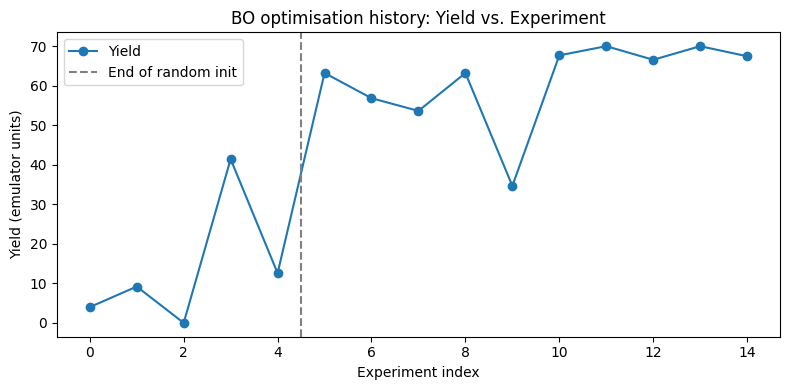

In [ ]:
# ── Plot yield vs. experiment index ─────────────────────────────────────
# Each point on the x-axis is one experiment (in chronological order).
# An upward trend indicates positive optimisation steps.

fig, ax = plt.subplots(figsize=(8, 4))
sobo_strategy.experiments["Yield"].plot(ax=ax, marker="o", linestyle="-")
ax.axvline(x=4.5, color="gray", linestyle="--", label="End of random init")
ax.set_xlabel("Experiment index")
ax.set_ylabel("Yield (emulator units)")
ax.set_title("BO optimisation history: Yield vs. Experiment")
ax.legend()
plt.tight_layout()
plt.show()

---

## Part 7 — Extension: Multi-Objective Bayesian Optimisation

### 🧠 Concept: Why multiple objectives?

In the single-objective case we maximised yield alone.  
In practice, chemists care about **multiple, often conflicting** objectives simultaneously:

| Objective | Direction | Chemistry rationale |
|---|---|---|
| **Yield** | Maximise | More product per reaction |
| **TON** | Maximise | Higher indicates more stable catalyst |


### 🧠 Concept: The Pareto Front

When two objectives conflict, there is no single "best" point.  
Instead there is a **Pareto front** — the set of solutions where you cannot improve one objective without worsening another.

```
Yield
  ▲
  │         ●  ← Pareto optimal (high yield, medium TON)
  │      ●     ← Pareto optimal (medium yield, low TON)
  │   ●        ← Pareto optimal (low yield, very low TON)
  │         ○  ← Dominated (worse than some Pareto point on both objectives)
  └──────────────▶ TON (lower is better)
```

### 🧠 Concept: `qEHVI` — Expected Hypervolume Improvement

`qEHVI` (Expected Hypervolume Improvement) is the standard acquisition function for multi-objective BO.  
It measures how much the current Pareto front's **dominated hypervolume** is expected to improve if we run a proposed experiment.  
A larger hypervolume = a better Pareto front (it dominates more of the objective space).

> ⚠️ **Computational cost:** Multi-objective BO is substantially slower than single-objective BO  
> because the hypervolume computation scales poorly with the number of Pareto points.  
> Expect each iteration to take 1–3 minutes on a CPU.


### Setting up the multi-objective domain and strategy

We need to:
1. Add a `TON` output with a `MaximizeObjective`.
2. Rebuild the `Domain` with both outputs.
3. Replace `SoboStrategy` + `qEI` with `MoboStrategy` + `qEHVI`.

Everything else (domain inputs, `RandomStrategy` for initialisation, the ask/tell loop) remains the same.


In [ ]:
from bofire.data_models.objectives.api import MinimizeObjective
from bofire.data_models.strategies.api import MoboStrategy
from bofire.data_models.acquisition_functions.api import qEHVI

# ── Objectives ────────────────────────────────────────────────────────────
# MaximizeObjective for yield: higher is better.
max_objective = MaximizeObjective(w=1.0)

# For demonstration purposes only:
# MinimizeObjective: lower is better.
# bounds=[0, 200] tells BOFire the expected range of TON values.
# These bounds are used to normalise TON internally.
min_objective = MinimizeObjective(w=1.0, bounds=[0, 200])

# ── Output features ───────────────────────────────────────────────────────
yield_feature = ContinuousOutput(key="Yield", objective=max_objective)
ton_feature   = ContinuousOutput(key="TON",   objective=max_objective)

# Outputs container now holds BOTH responses.
output_features = Outputs(features=[yield_feature, ton_feature])

# ── Rebuild Domain with multi-objective outputs ───────────────────────────
domain = Domain(
    inputs=input_features,   # Same inputs as before
    outputs=output_features,  # Now includes Yield AND TON
)

# ── Build the MOBO strategy ───────────────────────────────────────────────
# qEHVI : Expected Hypervolume Improvement acquisition function
qExpectedImprovement = qEHVI()

mobo_strategy_data_model = MoboStrategy(
    domain=domain,
    acquisition_function=qExpectedImprovement,
)

# Map to a runnable strategy object.
mobo_strategy = strategies.map(mobo_strategy_data_model)

In [ ]:
# ── Random initialisation for MOBO ──────────────────────────────────────
# Same pattern as the single-objective case:
# 1. Build a RandomStrategy on the NEW multi-output domain.
# 2. Ask for 5 random experiments.
# 3. Evaluate them with the emulator (which also returns TON).
# 4. Tell the MOBO strategy so it can fit its initial GP models.
from bofire.data_models.strategies.api import (
    RandomStrategy as RandomStrategyModel,
)

random_strategy_model = RandomStrategyModel(domain=domain)
random_strategy = strategies.map(random_strategy_model)

# Ask for 5 random candidates.
candidates = random_strategy.ask(5)

# Evaluate (emulator returns both Yield and TON).
renamed_candidates = candidates.rename(columns=name_map)
renamed_candidates = renamed_candidates.to_dict(orient="records")
print(renamed_candidates)
experiments = []
for candidate in renamed_candidates:
  print(candidate)
  experiments.append(perform_experiment([candidate]))
  print('-------')

flattened = [item for sublist in experiments for item in sublist]
df = pd.DataFrame(flattened)
reverse_name_map = {v: k for k, v in name_map.items()}
experiments = df.rename(columns=reverse_name_map)

# Initialise MOBO strategy with the random data.
# replace=True : start fresh (discard any earlier single-point data)
# retrain=True  : fit GPs for both outputs immediately
mobo_strategy.tell(experiments, replace=True, retrain=True)

[{'catalyst_loading': 0.5078595930661844, 't_res': 140.4860244998974, 'temperature': 101.81781676512156, 'catalyst': 'P1-L1'}, {'catalyst_loading': 0.6943532584628325, 't_res': 114.6376638500694, 'temperature': 65.88312014768955, 'catalyst': 'P2-L1'}, {'catalyst_loading': 0.7514139146640009, 't_res': 358.9300052429548, 'temperature': 92.64371522816617, 'catalyst': 'P1-L3'}, {'catalyst_loading': 0.7886592444496867, 't_res': 454.8559133789781, 'temperature': 91.56573810882986, 'catalyst': 'P1-L4'}, {'catalyst_loading': 1.9573707962734286, 't_res': 79.78538881098355, 'temperature': 78.51072208231335, 'catalyst': 'P1-L4'}]
{'catalyst_loading': 0.5078595930661844, 't_res': 140.4860244998974, 'temperature': 101.81781676512156, 'catalyst': 'P1-L1'}
[{'catalyst': 'P1-L1', 'catalyst_loading': 0.5078595931, 'iteration': 0, 't_res': 140.4860244999, 'temperature': 101.8178167651, 'ton': 0.0, 'yield': 23.3563842773}]
-------
{'catalyst_loading': 0.6943532584628325, 't_res': 114.6376638500694, 'temp

In [ ]:
# ── Multi-objective BO loop ───────────────────────────────────────────────
# Identical structure to the single-objective loop.
# The key differences are:
#   - mobo_strategy instead of sobo_strategy
#   - Each ask() step optimises qEHVI (hypervolume improvement) rather than qEI
#   - Each iteration is substantially slower due to the hypervolume calculation
#
# ⚠️  Expect ~1–3 minutes per iteration on a laptop CPU.
# Start with experimental_budget = 5 to confirm it works, then increase.

experimental_budget = 100  # ← Start small; each iteration takes ~1–3 minutes
i = 0
done = False

while not done:
    i += 1
    t1 = time.time()

    # Step 1: Ask for next experiment (maximises expected hypervolume improvement)
    new_candidate = mobo_strategy.ask(1)

    # Step 2: Evaluate with the emulator
    renamed_candidates = new_candidate.rename(columns=name_map)
    renamed_candidates = renamed_candidates.to_dict(orient="records")

    new_experiment = perform_experiment(renamed_candidates)

    df = pd.DataFrame(new_experiment)
    reverse_name_map = {v: k for k, v in name_map.items()}
    new_experiment_df = df.rename(columns=reverse_name_map)

    # Step 3: Update the MOBO strategy with both Yield and TON observations
    mobo_strategy.tell(new_experiment_df)

    print(f"Iteration {i:>3d} | Yield = {new_experiment_df['Yield'].values[0]:.3f} "
          f"| TON = {new_experiment_df['TON'].values[0]:.3f} "
          f"| took {(time.time()-t1):.1f}s")

    if i >= experimental_budget:
        done = True

print("\nMulti-objective optimisation complete!")

/usr/local/lib/python3.12/dist-packages/botorch/acquisition/multi_objective/monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration   1 | Yield = 67.756 | TON = 35.852 | took 23.3s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/multi_objective/monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration   2 | Yield = 51.982 | TON = 27.129 | took 22.2s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/multi_objective/monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


...

/usr/local/lib/python3.12/dist-packages/botorch/acquisition/multi_objective/monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration  10 | Yield = 60.394 | TON = 32.598 | took 28.4s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/multi_objective/monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Iteration  11 | Yield = 57.824 | TON = 70.427 | took 30.0s


/usr/local/lib/python3.12/dist-packages/botorch/acquisition/multi_objective/monte_carlo.py:110: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


---

## Part 8 — Analysing the Multi-Objective Results

### Visualising the Pareto front

After the MOBO loop, `mobo_strategy.experiments` contains both `Yield` and `TON` for every run.  
The most informative visualisation is a **2D scatter plot** of TON vs. Yield:

- Points on the **upper-right frontier** (high yield, high TON) approximate the Pareto front.
- Points in the **lower-left** are dominated — there exist experiments that are better on both objectives.

### Analysis questions

1. Can you identify the Pareto-optimal points by eye in the scatter plot?
2. Is there a visible trade-off (does increasing yield require higher TON)?
3. How do the multi-objective results compare to the single-objective optimum?
4. Which catalyst appears most often on the Pareto front?

> 💡 **Extension:** Use `bofire`'s built-in Pareto front utilities or implement your own filter:  
> a point (y₁, t₁) dominates (y₂, t₂) if `y₁ >= y₂` AND `t₁ <= t₂` (with at least one strict inequality).


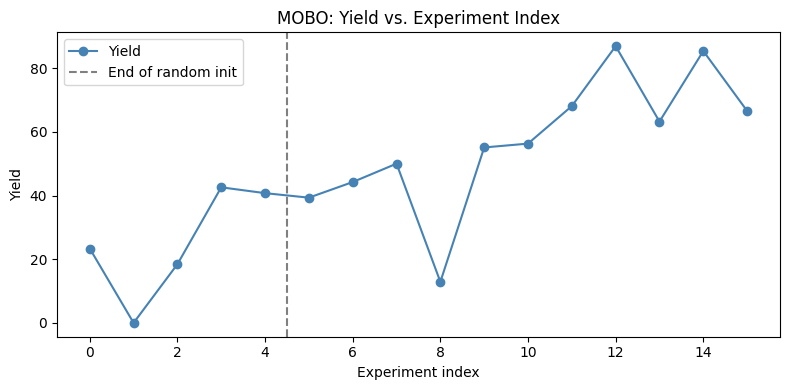

In [69]:
# ── Plot 1: Yield over iterations ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
mobo_strategy.experiments["Yield"].plot(ax=ax, marker="o", linestyle="-", color="steelblue")
ax.axvline(x=4.5, color="gray", linestyle="--", label="End of random init")
ax.set_xlabel("Experiment index")
ax.set_ylabel("Yield")
ax.set_title("MOBO: Yield vs. Experiment Index")
ax.legend()
plt.tight_layout()
plt.show()

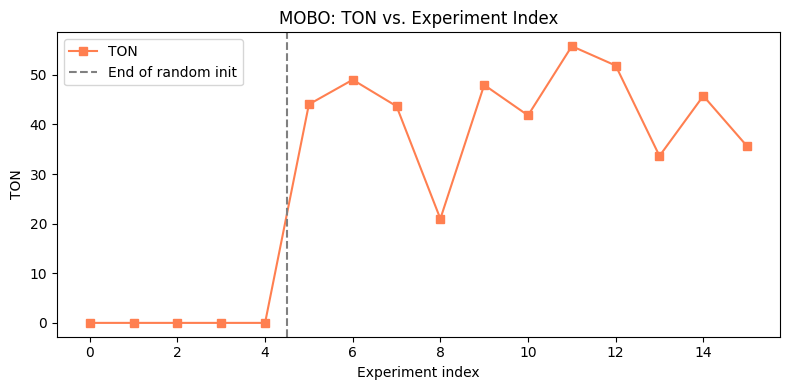

In [70]:
# ── Plot 2: TON over iterations ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
mobo_strategy.experiments["TON"].plot(ax=ax, marker="s", linestyle="-", color="coral")
ax.axvline(x=4.5, color="gray", linestyle="--", label="End of random init")
ax.set_xlabel("Experiment index")
ax.set_ylabel("TON")
ax.set_title("MOBO: TON vs. Experiment Index")
ax.legend()
plt.tight_layout()
plt.show()

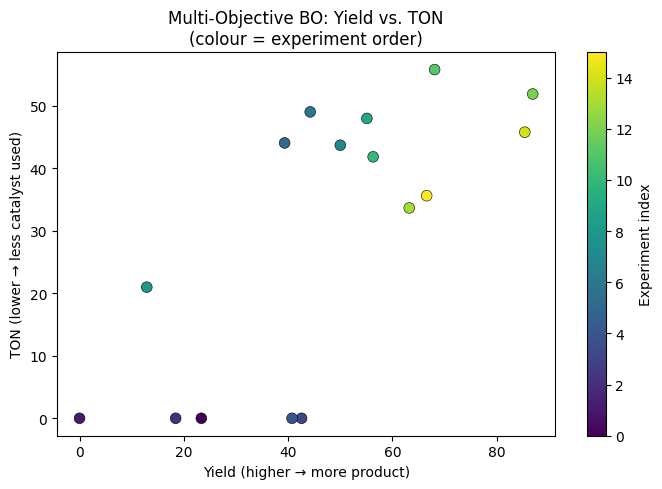


Summary statistics:
        Yield     TON
count  16.000  16.000
mean   47.082  29.384
std    24.759  21.938
min     0.000   0.000
25%    35.342   0.000
50%    47.129  38.714
75%    64.075  46.308
max    86.926  55.777


In [72]:
# ── Plot 3: Pareto scatter plot ──────────────────────────────────────────
# This is the most informative MOBO visualisation.
# Each point is one experiment. Points on the upper-left frontier are Pareto-optimal.

df = mobo_strategy.experiments
fig, ax = plt.subplots(figsize=(7, 5))

# Colour-code by iteration index to show how the front evolves.
scatter = ax.scatter(df["Yield"], df["TON"],
                     c=df.index, cmap="viridis", s=60, edgecolors="k", linewidths=0.4)
plt.colorbar(scatter, ax=ax, label="Experiment index")

ax.set_ylabel("TON (lower → less catalyst used)")
ax.set_xlabel("Yield (higher → more product)")
ax.set_title("Multi-Objective BO: Yield vs. TON\n(colour = experiment order)")
plt.tight_layout()
plt.show()

print("\nSummary statistics:")
print(df[["Yield", "TON"]].describe().round(3))

---

## 📝 Summary

In this notebook you have:

1. **Defined** a `Domain` with continuous and categorical inputs, and a yield output with a `MaximizeObjective`.
2. **Used** a pre-trained neural network emulator as a virtual lab stand-in.
3. **Initialised** a GP-based BO strategy with random experiments.
4. **Implemented** the ask–evaluate–tell loop for single-objective BO.
5. **Interpreted** the optimisation history and identified the best conditions.
6. **Extended** the setup to multi-objective BO with `MoboStrategy` and `qEHVI`.
7. **Visualised** the Pareto front showing the yield–TON trade-off.

### Further reading

- [BOFire documentation](https://experimental-design.github.io/bofire/)
- [BoTorch — the underlying GP/acquisition library](https://botorch.org/)
- [Summit — reaction emulators](https://github.com/sustainable-processes/summit)
- Shields, B.J. et al. *Bayesian reaction optimisation as a tool for chemical synthesis.* Nature 590, 89–96 (2021).
- Hernández-Lobato, J.M. et al. *Predictive Entropy Search for Multi-objective Bayesian Optimization.* NeurIPS 2016.
